# Week 4 Problem Set

## Homeworks

In [99]:
%load_ext nb_mypy
%nb_mypy Off

The nb_mypy extension is already loaded. To reload it, use:
  %reload_ext nb_mypy


In [100]:
from typing import TypeAlias
from typing import Optional, Any
from typing import Callable
from __future__ import annotations


Number: TypeAlias = int | float

**HW1**. Design a class named `Stock` to represent a company's stock that contains:
* a string attribute named `symbol` for the stock's symbol.
* a string attribute named `name` for the stock's name.
* a float property named `previous_closing_price` that stores the stock's price for the previous day. The value of the previous closing price must always be a positive number.
* a float property named `current_price` that stores the stock price for the current time. Similarly, the current stock price must always be  positive number.
* an initializer that initializes the new stock object with the specified symbol, name, previous price and current price. 
* a method named `get_change_percent()` that returns the percentage changed from previous closing price to current price.

Prices must be positive.

In [101]:
class Stock:
    def __init__(self, symbol, name, previous_price, current_price):
        self.symbol = symbol
        self.name = name
        self._previous_closing_price = previous_price
        self._current_price = current_price
        pass

    @property
    def previous_closing_price(self) -> Number:
        return self._previous_closing_price
    
    @previous_closing_price.setter
    def previous_closing_price(self,val: Number) -> None:
        if val >= 0:
            self._previous_closing_price = val

    @property
    def current_price(self) -> Number:
        return self._current_price

    @current_price.setter
    def current_price(self, val:Number) -> None:
        if val >= 0:
            self._previous_closing_price = val

    def get_change_percent(self) -> Number:
        change = self.current_price - self.previous_closing_price
        return change/self.previous_closing_price * 100

In [102]:
s: Stock = Stock("INTC", "Intel Corporation", 20.5, 20.35)
assert s.symbol == "INTC"
assert s.name == "Intel Corporation"
assert s.previous_closing_price == 20.5
assert s.current_price == 20.35
assert round(s.get_change_percent(),2) == -0.73
s.current_price = -100
assert s.current_price == 20.35

In [103]:
### BEGIN HIDDEN TESTS
s: Stock = Stock("AAPL", "Apple Inc", 253.205, 207.35)
assert s.symbol == "AAPL"
assert s.name == "Apple Inc"
assert s.previous_closing_price == 253.205
assert s.current_price == 207.35
assert round(s.get_change_percent(),2) == -18.11
s.current_price = -100
assert s.current_price == 207.35
### END HIDDEN TESTS


**HW2.** We are going to create a class that contains both `RobotTurtle` and `Coordinate` class. The name of the class is `TurtleWorld` which is used to simulate when `RobotTurtle` is moving around some two dimensional space. The class has the following methods:

- `add_turtle(name)` which is to add a new `RobotTurtle` into the world with the specified name.
- `remove_turtle(name)` which is to remove the object `RobotTurtle` with the specified name from the world. 
- `list_turtles()` which is to list all the turtles in the world using their names in an ascending order.

We give you here the class definition for the `Coordinate` and the `RobotTurtle` from the Notes.

In [104]:
import math

class Coordinate:
    
    def __init__(self, x: Number=0, y: Number=0):
        self.x: Number = x
        self.y: Number = y
        
    @property
    def distance(self) -> Number:
        return math.sqrt(self.x * self.x + self.y * self.y)
    
    def __str__(self) -> str:
        return f"({self.x}, {self.y})"

In [105]:
# Class definition
class RobotTurtle:
    # Attributes:
    def __init__(self, name: str, speed: int=1) -> None:
        assert isinstance(name, str) and name != ""
        assert isinstance(speed, int) and speed > 0
        self._name: str = name
        self._speed: int = speed
        self._pos: Coordinate = Coordinate(0, 0)
        
    # property getter
    @property
    def name(self) -> str:
        return self._name
    
    # property setter
    @name.setter
    def name(self, value: str) -> None:
        if isinstance(value, str) and value != "":
            self._name = value
            
    # property getter
    @property
    def speed(self) -> int:
        return self._speed
    
    # property setter
    @speed.setter
    def speed(self, value: int) -> None:
        if isinstance(value, int) and value > 0:
            self._speed = value

    # property getter
    @property
    def pos(self) -> Coordinate:
        return self._pos
    
    # Methods:
    def move(self, direction: str) -> None:
        update: dict[str, Coordinate] = {'up' : Coordinate(self.pos.x, self.pos.y + self.speed),
                                        'down' : Coordinate(self.pos.x, self.pos.y - self.speed),
                                        'left' : Coordinate(self.pos.x - self.speed, self.pos.y),
                                        'right' : Coordinate(self.pos.x + self.speed, self.pos.y)}
        self._pos = update[direction]

        
    def tell_name(self) -> None:
        print(f"My name is {self.name}")


Now fill in the class definition for `TurtleWorld`. You may want to look into the test cases in the following cell to make sure you define the class properly.

In [106]:
class TurtleWorld:
    
    def __init__(self) -> None:
        self.turtles: dict[str, RobotTurtle] = {}
        
    def add_turtle(self, name: str, speed: int) -> None:
        turtle = RobotTurtle(name,speed)
        self.turtles[name] = turtle
        
    def remove_turtle(self, name: str) -> None:
        self.turtles.pop(name)
        pass
        
    def list_turtles(self) -> list[str]:
        return sorted(self.turtles.keys())
        pass

In [107]:
world: TurtleWorld = TurtleWorld()
world.add_turtle('t1', 1)
assert world.list_turtles() == ['t1']

world.add_turtle('t2', 2)
assert world.list_turtles() == ['t1', 't2']

world.add_turtle('abc', 3)
assert world.list_turtles() == ['abc', 't1', 't2']

world.remove_turtle('t2')
assert world.list_turtles() == ['abc', 't1']

world.remove_turtle('abc')
assert world.list_turtles() == ['t1']

In [108]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###

**HW3.** Modify the class `TurtleWorld` to add the following method:
- `move_turtle(name, movement)` which is to move the turtle with the specified name with a given input `movement`. The argument `movement` is a string containing letters: `l` for left, `r` for right, `u` for up, and `d` for down. The movement should be based on the speed. This means that if the turtle has speed of 2 and the `movement` argument is `uulrdd`, the turtle should move up four units, move left two units, move right two units and move down four units.

In [109]:
class TurtleWorld:
    valid_movements: set[str] = set('udlr')
    movement_map: dict[str, str] = {'u': 'up', 'd': 'down', 'l': 'left', 'r': 'right'}
    
    def __init__(self) -> None:
        self.turtles: dict[str, RobotTurtle] = {}
        
    def move_turtle(self, name: str, movement: str) -> None:
        for c in movement:
            if c in self.valid_movements:
                self.turtles[name].move(self.movement_map[c])
    
    def add_turtle(self, name: str, speed: int) -> None:
        turtle = RobotTurtle(name,speed)
        self.turtles[name] = turtle
        
    def remove_turtle(self, name: str) -> None:
        self.turtles.pop(name)
        
    def list_turtles(self) -> list[str]:
        return sorted(self.turtles.keys())

In [110]:
world: TurtleWorld = TurtleWorld()
world.add_turtle('abc', 1)
world.move_turtle('abc', 'uu')
assert str(world.turtles['abc'].pos) == '(0, 2)'

world.move_turtle('abc', 'rrr')
assert str(world.turtles['abc'].pos) == '(3, 2)'

world.move_turtle('abc', 'd')
assert str(world.turtles['abc'].pos) == '(3, 1)'

world.move_turtle('abc', 'llll')
assert str(world.turtles['abc'].pos) == '(-1, 1)'

world.add_turtle('t1', 2)
world.move_turtle('t1', 'uulrdd')
assert str(world.turtles['t1'].pos) == '(0, 0)'

world.move_turtle('t1', 'ururur')
assert str(world.turtles['t1'].pos) == '(6, 6)'

In [111]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###

**HW4.** Extend the class `Fraction` to implement the other operators: `- * < <= > >=`.

In [ ]:
def gcd(a: int, b: int) -> int:
    if b == 0:
        return a
    else:
        return gcd(b, a % b)


class Fraction:
    def __init__(self, num: int, den: int) -> None:
        assert isinstance(num, int)
        assert isinstance(den, int)
        self._num = num
        self._den = 0 if den == 0 else den
        pass
        

    @property
    def num(self) -> int:
        return self._num
    
    @num.setter
    def num(self, val: int) -> None:
        if isinstance(val,int):
            self._num = val
    
    @property
    def den(self) -> int:
        return self._den
    
    @den.setter
    def den(self, val: int) -> None:
        if isinstance(val, (float,int)):
            if val == 0:
                self._den = 1
            else: 
                self._den = int(val)
    
    def __str__(self) -> str:
        return f'{self._num}/{self._den}'
    
    def simplify(self) -> Fraction:
        div_by = gcd(self._num,self._den)
        simple_num = self.num//div_by
        simple_den = self.den//div_by
        return Fraction(simple_num,simple_den)
    
    def __add__(self, other) -> Fraction:
        numerator = self._num * other._den + other._num * self._den
        denominator = self._den * other._den
        return Fraction(numerator, denominator).simplify()
        
    def __eq__(self, other) -> bool:
        simple_self = self.simplify()
        simple_other = other.simplify()
        return simple_self._den == simple_other._den and simple_self._num == simple_other.num
        
    def __sub__(self, other) -> Fraction:
        numerator = self._num * other._den - other._num * self._den
        denominator = self._den * other._den
        return Fraction(numerator, denominator).simplify()
    
    def __mul__(self, other) -> Fraction:
        numerator = self._num * other._num
        denominator = self._den * other._den
        return Fraction(numerator, denominator).simplify()
    
    def __lt__(self, other) -> bool:
        return self._num * other._den < other._num * self._den
    
    def __le__(self, other) -> bool:
        return self._num * other._den <= other._num * self._den

    
    def __gt__(self, other) -> bool:
        return self._num * other._den > other._num * self._den

    
    def __ge__(self, other) -> bool:
        return self._num * other._dxen >= other._num * self._den

In [113]:
f1: Fraction = Fraction(3, 4)
f2: Fraction = Fraction(1, 2)
f3: Fraction = f1 - f2
assert f3 == Fraction(1, 4)
f4: Fraction = f1 * f2
assert f4 == Fraction(3, 8)
assert f2 < f1
assert f2 <= f2
assert f1 > f3
assert f3 >= f3

In [114]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###

**HW5.** Implement the `Queue` abstract data structure using a Class. The class should have the following interface:
- `__init__()` to initialize an empty List for the queue to store the items.
- `enqueue(item)` which inserts an item into the queue.
- `dequeue()` which returns and removes the element at the head of the queue. The return value is an optional as it may return `None` if there are no more elements in the queue.
- `peek()` which returns the element at the head of the queue. If there are no elements in the Queue, return `None`.

The class Queue has two computed properties:
- `is_empty` which returns either `True` or `False` depending on whether the queue is empty or not.
- `size` which returns the number of items in the queue.

In [115]:
class Queue:
    def __init__(self) -> None:
        self.__items: list[Any] = []
    
    def enqueue(self, item: Any) -> None:
        self.__items.append(item)

    def dequeue(self) -> Any:
        return self.__items.pop(0)
    
    def peek(self) -> Any:
        if not self.is_empty:
            return self.__items[0]


    @property
    def is_empty(self) -> bool:
        return self.size == 0
    
    @property
    def size(self) -> int:
        return len(self.__items)


In [116]:
q1: Queue = Queue()
q1.enqueue(2)
assert not q1.is_empty
assert q1.size == 1
ans = q1.dequeue()
assert ans == 2
assert q1.is_empty
q1.enqueue(1)
q1.enqueue(2)
q1.enqueue(3)
assert q1.size == 3
assert q1.peek() == 1
assert q1.dequeue() == 1
assert q1.dequeue() == 2
assert q1.dequeue() == 3
assert q1.peek() is None

In [117]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###

In [118]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###

**HW6.** You need to complete the previous questions before attempting this question.**

Now let us measure the computation time for list based implementation of `Queue`.

There are a few parts you need to fill up.
- `enqueue(q, array)`, to enqueue every element in the array to the Queue `q`.
- `dequeue(q)`, to dequeue every element in from the Queue `q`.
- `measure_enq_deq_time(power)`, to create a random array of size $10^{power}$ and call `run_function()` on `enqueue/dequeue` to measure the time taken.

Note: Since `enqueue()` needs 2 arguments and `dequeue()` needs only 1, we need to let `run_function()` accept any number of arguments. `*args` allows us to achieve this.

In [119]:
import time
import random

def run_function(f: Callable, q: Queue, array: list[Number]) -> float:
    start: float = time.time()
    f(q, array)
    end: float = time.time()
    return end-start


def enqueue(q: Queue, array: list[Number]) -> None:
    for item in array:
        q.enqueue(item)

def dequeue(q: Queue, dummy: list) -> None:
    while not q.is_empty:
        q.dequeue()
    pass

# set the maximum power for 10^power number of inputs
maxpower: int = 5
powers = list(range(1, maxpower + 1))

def measure_enq_deq_time(power: int) -> tuple[float, float]:

    # create array for 10^1, 10^2, 10^3, etc
    array = list(range(10 ** power))

    # use random seed = 100 to randomize the array
    random.seed(100)
    random.shuffle(array)

    # create a queue object instance
    q: Queue = Queue()

    # call run_function for enqueue()
    time_enqueue = run_function(enqueue, q, array)

    # call run_function for dequeue()
    # since dequeue does not require any input array,
    # pass on an empty list to the third argument
    time_dequeue = run_function(dequeue, q, [])

    return time_enqueue, time_dequeue


time_enqueue_list: list[float] = []
time_dequeue_list: list[float] = []

for power in powers:
    time_enqueue, time_dequeue = measure_enq_deq_time(power)
    time_enqueue_list.append(time_enqueue)
    time_dequeue_list.append(time_dequeue)

print(time_enqueue_list)
print(time_dequeue_list)

[1.9073486328125e-06, 5.4836273193359375e-06, 2.86102294921875e-05, 0.0014986991882324219, 0.014173269271850586]
[5.0067901611328125e-06, 7.62939453125e-06, 8.96453857421875e-05, 0.0037882328033447266, 0.3806302547454834]


Now we will time the double-stack Queue implementation from your cohort problems.

Copy-paste the Stack class and the double-stack Queue class from your cohort problems.

In [120]:
class Stack:
    def __init__(self) -> None:
        self.__items: list[Any] = []
        
    def push(self, item: Any):
        self.__items.append(item)

    def pop(self) -> Any:
        if not self.is_empty:
            return self.__items.pop()

    def peek(self) -> Any:
        if not self.is_empty:
            return self.__items[-1]

    @property
    def is_empty(self) -> bool:
        return self.size == 0

    @property
    def size(self):
        return len(self.__items)


In [121]:
class Queue:

    def __init__(self):
        self.in_stack = Stack()
        self.out_stack = Stack()

    def enqueue(self, item):
        self.in_stack.push(item)

    def dequeue(self):
        if self.out_stack.is_empty:
            while not self.in_stack.is_empty:
                self.out_stack.push(self.in_stack.pop())

        return self.out_stack.pop()

    def peek(self):
        if self.out_stack.is_empty:
            while not self.in_stack.is_empty:
                self.out_stack.push(self.in_stack.pop())

        return self.out_stack.peek()

    @property
    def is_empty(self):
        return self.in_stack.is_empty and self.out_stack.is_empty

    @property
    def size(self):
        return self.in_stack.size + self.out_stack.size

Measure the computational time for operations on a double-stack based Queue implementation.

Note that we don't have to modify `measure_enq_deq_time` at all, since we simply swapped out the `Queue` class. That is why abstract data classes are important -- as long as the new `Queue` class includes methods `enqueue` and `dequeue`, the user does not need to know how the queue is implemented.

In [122]:
time_enqueue_stack: list[float] = []
time_dequeue_stack: list[float] = []

for power in powers:
    time_enqueue, time_dequeue = measure_enq_deq_time(power)
    time_enqueue_stack.append(time_enqueue)
    time_dequeue_stack.append(time_dequeue)

print(time_enqueue_stack)
print(time_dequeue_stack)

[3.814697265625e-06, 6.9141387939453125e-06, 6.127357482910156e-05, 0.0006136894226074219, 0.015292882919311523]
[1.049041748046875e-05, 3.314018249511719e-05, 0.0003180503845214844, 0.006499052047729492, 0.0581204891204834]


Compare with the list-based Queue implementation. Which one is faster? Why?

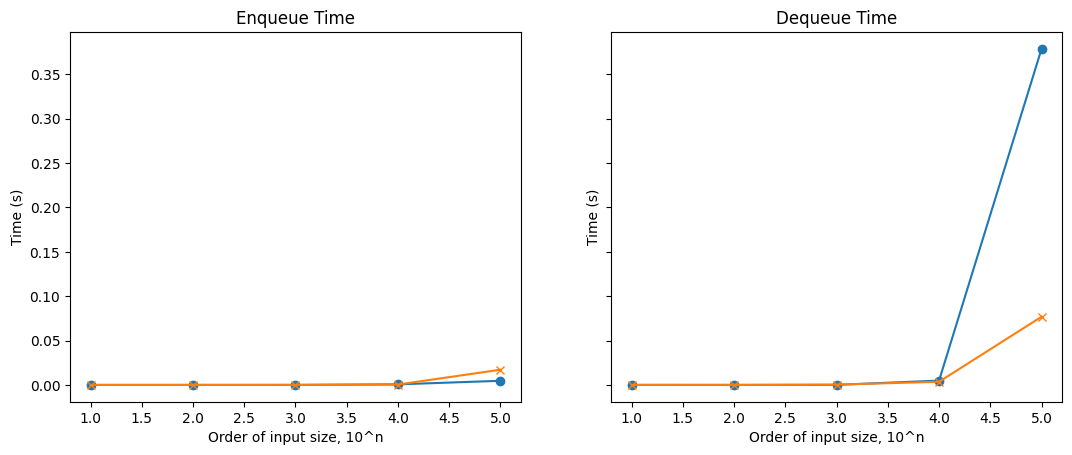

In [98]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(ncols=2, sharey=True)
width, height = fig.get_size_inches()
fig.set_size_inches(w=width * 2, h=height)

axes[0].plot(powers, time_enqueue_list,'o-')
axes[0].plot(powers, time_enqueue_stack,'x-')
axes[0].set_ylabel("Time (s)")
axes[0].set_xlabel("Order of input size, 10^n")
axes[0].set_title("Enqueue Time");

axes[1].plot(powers, time_dequeue_list,'o-')
axes[1].plot(powers, time_dequeue_stack,'x-')
axes[1].set_ylabel("Time (s)")
axes[1].set_xlabel("Order of input size, 10^n")
axes[1].set_title("Dequeue Time");